# Flash Drought Indicators

This notebook will introduce the two remote sensing datasets that we will be using as flash drought indicators in this course:
* Solar-Induced Fluorescence (SIF) data in the form of the [GOSIF dataset](https://globalecology.unh.edu/data/GOSIF.html)
* Root-zone Soil Moisture (SM) data from the [SMAP L4 Global 3-hourly 9 km dataset](https://search.earthdata.nasa.gov/search/granules/collection-details?p=C3480440870-NSIDC_CPRD)
* Soil Water Deficit Index (SWDI) derived from ERA-5 Land

### Why are we using these datasets?

The motivation for using SIF and SM data for detecting flash drought comes from an "impact-centric framework" developed by Koushan Mohammadi and Guiling Wang of the University of Connecticut. \[[3](https://doi.org/10.1073/pnas.2202767119)\]\[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\] Traditionally, drought was seen as a primarily climatological phenomenon where a deficit in precipitation and higher than normal temperatures were the key metrics used for detection \[[1](https://doi.org/10.46275/JOASC.2021.02.001)\]\[[2](https://doi.org/10.1002/wat2.1714)\]. Agricultural droughts are, however, assessed in terms of their impacts on cropland above any other factors, so the determination as to whether a precipitation deficit is material to crop growth depends on the crop type, existing soil moisture, and the climate of the growing region being studied. It is far more effective, therefore, to use land-process based metrics like SIF and SM to detect flash drought than it is to use metrics like temperature and precipitation. 

## Solar-Induced Chlorophyll Flourescence

SIF data can be thought of as a measure of the photosynthetic activity of plants in aggregate. The ARSET program has produced several courses on this data if you would like to learn more about this exciting measurement: [Solar Induced Fluorescence (SIF) Observations for Assessing Vegetation Changes Related to Floods, Drought, and Fire Impacts](https://www.earthdata.nasa.gov/learn/trainings/solar-induced-fluorescence-sif-observations-assessing-vegetation-changes-related). As most instruments capable of measuring SIF data from space right now are limited in terms of their spatial coverage and observational record, we will be relying on a gap-filled dataset called [GOSIF](https://globalecology.unh.edu/data/GOSIF.html) produced by Xing Li and Jingfeng Xiao of the University of New Hampshire (UNH). \[[10](https://doi.org/10.3390/rs11050517)\] Gap-filled data like GOSIF combines OCO-2 observations with a secondary source like Terra and Aqua MODIS to both fill in spatial gaps in the data and allow the SIF measurement to be extrapolated past the time range of the OCO-2 mission, which launched in 2014. Mohammadi and Wang use the GOME-2 and Contiguous SIF (CSIF) products in their own research as data sources, but GOSIF offers the same 8-day temporal resolution used in \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\] and has publicly accessible data from 2000-2024.

In this first section, we will download a time range of GOSIF data from the UNH repository and unpack it into GeoTIFF format.

In [1]:
import os
from tqdm.notebook import tqdm

from download import download_unpack_gosif

year = 2017
# Our time series will cover the growing season from DOY 73-298, but to calculate the SIF-RCI for the year
# we need to download data going back to the beginning of the year.
doy_range = range(1, 298, 8)

output_dir = "data/gosif"
os.makedirs(output_dir, exist_ok=True)

gosif_geotiffs: list[str] = []
for doy in tqdm(doy_range, desc="Downloading granules"):
    fname = download_unpack_gosif(
        year,
        day=doy,
        output_dir=output_dir,
        verbose=False
    )
    if fname:
        gosif_geotiffs.append(fname)

## Creating Time Series of SIF, SIF Standardized Anomaly and SIF-RCI

Now that we've retrieved our data, we can create a time series of the average SIF value over the region of interest and plot it compared to the mean climatology over the period 2001-2020. In our first case study, we will use the Northern Great Plains region of the US defined in the Mohammadi and Wang paper as 45.00°-50.00°N and 106.00°-111°W \[[4](https://doi.org/10.1175/BAMS-D-24-0143.1)\]. We will use the rasterio library to perform this calculation. The climatology information comes from a set of pre-processed files in the `inputs/sif_increments` directory that were generated by the `3_appendix.ipynb` notebook. The geotiffs in this directory are structured with three bands:

- Band 1: $\overline{\Delta \mathrm{SIF}_j}$, the mean increment of SIF for the jth 8-day window over the period 2001-2020
- Band 2: $\sigma_{\Delta \mathrm{SIF}_j}$, the standard deviation in the increment of SIF for the jth 8-day window over the period 2001-2020
- Band 3: $\overline{\mathrm{SIF}_j}$, the mean SIF for the jth 8-day window over the period 2001-2020

We have provided these values per grid cell over the region of interest because the z-score and SIF-RCI should be computed per grid cell before spatial averaging to be statistically rigorous.

In this next cell, we will create a CSV file with the various time series we intend to use as flash drought indicators:
- $\mathrm{SIF}_{j, y}$, the SIF value from year $y$ (2017 in this case) and time window $j$. This is not used as a drought indicator on its own, but we will plot it anyways.
- $\overline{\mathrm{SIF}_j}$, this is a spatial averaging of the Band 3 climatology data mentioned above. It is also not a drought indicator on its own, and we will just use it for comparison in our first plot.
- $Z(j, y)$, "SIF Standardized Anomaly" or z-score for the jth 8-day window in year $y = 2017$
- $\mathrm{RCI}(j, y)$, the SIF Rapid Change Index (RCI) for the jth 8-day window in year $y = 2017$

The z-score of SIF Standardized Anomaly, can be calculated as follows:

$$
Z(j, y) = \frac{\Delta \mathrm{SIF}_{j, y} - \overline{\Delta \mathrm{SIF}_j}}{\sigma_{\Delta \mathrm{SIF}_j}}
$$

We do this per grid cell over the region of interest and then spatially average the data to get the value in the time series.

Likewise, the SIF-RCI can be calculated in a piecewise recursive manner using the z-scores:

$$
\mathrm{RCI}(j, y) =
\begin{cases}
  \mathrm{RCI}(j-1, y) - \sqrt{|Z(j, y)| - 0.75},  & \text{if } Z(j, y) \lt -0.75, \\
  \mathrm{RCI}(j-1, y) + \sqrt{Z(j, y) - 0.75},    & \text{if } Z(j, y) \gt 0.75, \\
  0,                                               & \text{if } Z(j-1, y)*Z(j, y) \lt 0.
\end{cases}
$$

In [2]:
import csv
from datetime import datetime
from glob import glob

import numpy as np
import rasterio
from rasterio.windows import from_bounds

# Set the filename to use for the time series
time_series_fname = "northern_great_plains_2017_sif.csv"
# Get the climatology inputs produced by the appendix notebook
clim_geotiffs = sorted(glob("inputs/sif_increments/GOSIF_dSIF_clim_???.tif"))

# Northern Great Plains region of interest
# 45.00°–50.00°N, 106.00°–111.00°W
west, south, east, north = -111.0, 45.0, -106.0, 50.0

# The threshold and scale factor parameters come from the documentation: https://data.globalecology.unh.edu/data/GOSIF_v2/Fair_Data_Use_Policy_and_Readme_GOSIF_v2.pdf
# 32767 = water bodies, 32766 = ice/snow
gosif_data_thresh = 32765
# This value tells our code the conversion between pixel values in the GeoTIFF images to units of W/m^2/sr/μm
gosif_scale_factor = 0.0001

with rasterio.open(gosif_geotiffs[0]) as src:
    read_window = from_bounds(west, south, east, north, src.transform)
    read_window = read_window.round_offsets().round_lengths()


def read_roi(path: str) -> np.ndarray:
    """Read the ROI, mask non-data (water/ice/fill), scale to physical units."""
    with rasterio.open(path) as src:
        arr = src.read(1, window=read_window).astype("float64")
    arr[arr > gosif_data_thresh] = np.nan
    return arr * gosif_scale_factor


def compute_rci(
        z_jy_grid: np.ndarray,
        z_prev_grid: np.ndarray,
        rci_prev_grid: np.ndarray
) -> np.ndarray:
    """Compute the per grid cell SIF-RCI using the formula from above."""
    neg_anom = z_jy_grid < -0.75                  # Z(j,y) < -0.75       (case 1)
    pos_anom = z_jy_grid > 0.75                   # Z(j,y) >  0.75       (case 2)
    sign_change = (z_prev_grid * z_jy_grid) < 0   # Z(j-1,y)·Z(j,y) < 0  (case 3)

    neg_term = np.sqrt(np.where(neg_anom, np.abs(z_jy_grid) - 0.75, 0.0))
    pos_term = np.sqrt(np.where(pos_anom, z_jy_grid + 0.75, 0.0))

    rci_jy_grid = rci_prev_grid.copy()
    rci_jy_grid = np.where(neg_anom, rci_prev_grid - neg_term, rci_jy_grid)
    rci_jy_grid = np.where(pos_anom, rci_prev_grid + pos_term, rci_jy_grid)
    rci_jy_grid = np.where(sign_change, 0.0, rci_jy_grid)
    return rci_jy_grid


prev_grid: np.ndarray | None = None
# Initialize the arrays for the rows of our CSV
# The variable names correspond to what is mentioned in the description above
dates: list[datetime] = []
sif_jy: list[float] = []
mean_sif_j: list[float] = []
z_jy: list[float] = []
rci_jy: list[float] = []

# Recursive state carried between time windows for RCI.
# RCI(j0, y) = 0 and Z(j0, y) = 0 everywhere
# For simplicity, our incon j0 = DOY 1
rci_prev_grid: np.ndarray = np.zeros((read_window.height, read_window.width))
z_prev_grid: np.ndarray = np.zeros((read_window.height, read_window.width))

for j, geotiff in enumerate(gosif_geotiffs[1:], start=1):
    # Parse the date from the filename, e.g. GOSIF_2017073.tif = DOY 73
    doy = os.path.splitext(os.path.basename(geotiff))[0][-3:]
    dates.append(datetime.strptime(f"{year}{doy}", "%Y%j"))

    sif_grid = read_roi(geotiff)
    if j == 1:
        prev_grid = read_roi(gosif_geotiffs[j-1])
    # Get the SIF increment at j
    dsif_grid = sif_grid - prev_grid
    # Set the current raster to the previous for the next iteration
    prev_grid = sif_grid

    # Get the climatology input file produced by the appendix notebook
    clim_input = f"inputs/sif_increments/GOSIF_dSIF_clim_{doy}.tif"
    with rasterio.open(clim_input) as clim_src:
        mean_dsif_band = clim_src.read(1).astype(float)
        std_dsif_band = clim_src.read(2).astype(float)
        mean_sif_band = clim_src.read(3).astype(float)

    z_jy_grid = (dsif_grid - mean_dsif_band) / std_dsif_band

    rci_jy_grid = compute_rci(z_jy_grid, z_prev_grid, rci_prev_grid)
    z_prev_grid = z_jy_grid
    rci_prev_grid = rci_jy_grid

    rci_masked = np.where(np.isnan(z_jy_grid), np.nan, rci_jy_grid)

    # Compute the spatial average at the end
    sif_jy.append(float(np.nanmean(sif_grid)))
    mean_sif_j.append(float(np.nanmean(mean_sif_band)))
    z_jy.append(float(np.nanmean(z_jy_grid)))
    rci_jy.append(float(np.nanmean(rci_masked)))

# Save the output as a CSV so it can be used in the next notebook
csv_path = os.path.join("data", time_series_fname)
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["date", "sif", "mean_sif", "zscore", "sif_rci"])
    # We have 4 sig figs from the source data
    writer.writerows(
        zip(
            [d.strftime("%Y-%m-%d") for d in dates],
            [f"{sjy:.4f}" for sjy in sif_jy],
            [f"{msj:.4f}" for msj in mean_sif_j],
            [f"{zjy:.4f}" for zjy in z_jy],
            [f"{rjy:.4f}" for rjy in rci_jy],
        )
    )

print(f"Computed time series values for {len(dates)} granules and saved to {csv_path}")


Computed time series values for 37 granules and saved to data/northern_great_plains_2017_sif.csv


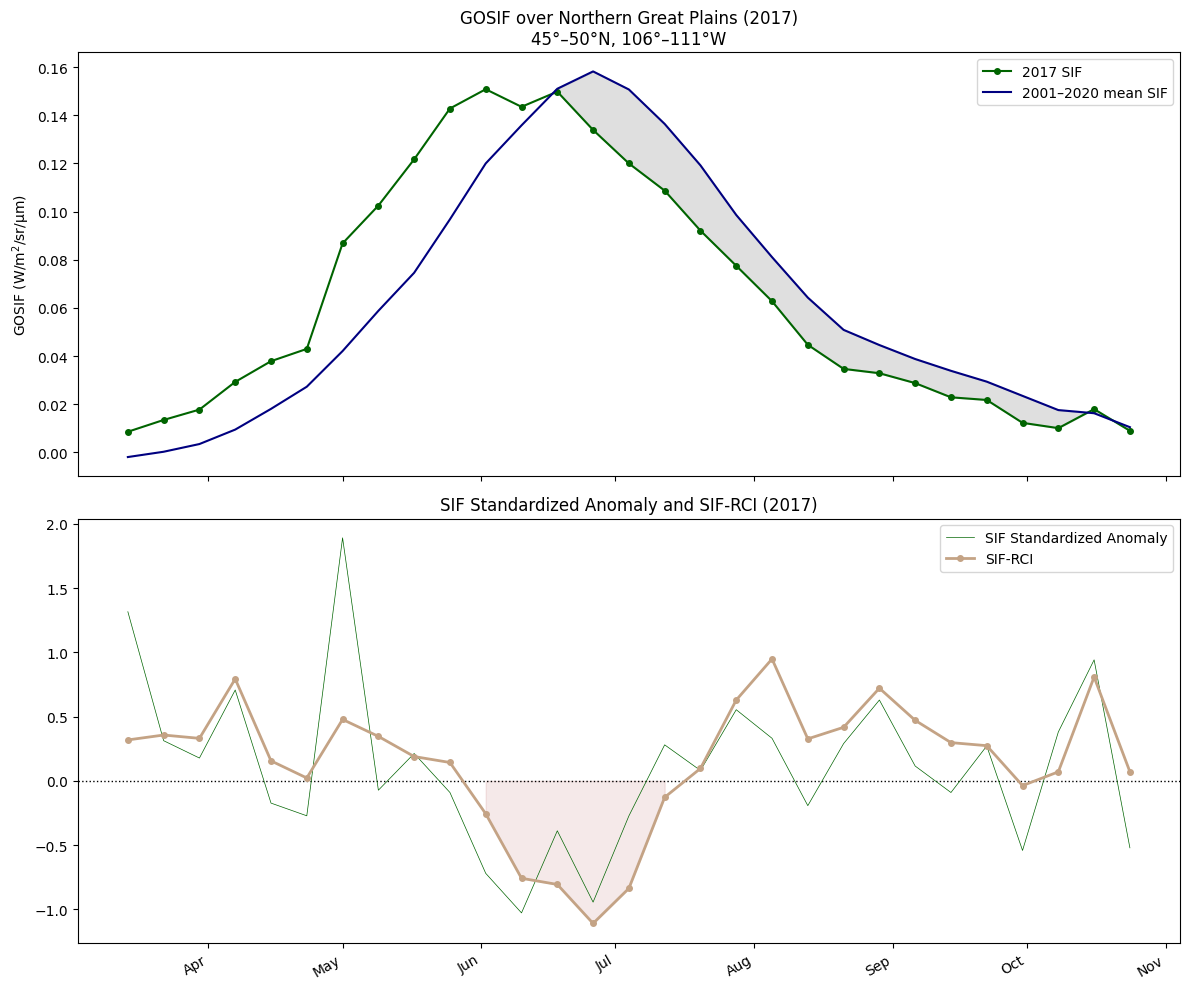

In [3]:
import csv

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_doy_start = 73
plot_doy_end = 298

# Read the saved CSV
plot_dates = []
plot_sif: list[float] = []
plot_mean_sif: list[float] = []
plot2_zscore: list[float] = []
plot2_sifrci: list[float] = []
with open(csv_path, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pt_date = datetime.strptime(row["date"], "%Y-%m-%d")
        doy = int(pt_date.strftime("%j"))
        if doy < plot_doy_start or doy > plot_doy_end:
            continue
        plot_dates.append(pt_date)
        plot_sif.append(float(row["sif"]))
        plot_mean_sif.append(float(row["mean_sif"]))
        plot2_zscore.append(float(row["zscore"]))
        plot2_sifrci.append(float(row["sif_rci"]))

# In the first plot, let's highlight the region where 2017 observed SIF
# was below the mean SIF for that time of year
# Note that there are small "fudge factors" in this statement and the one below,
# these are not to be used for actual analysis but are just used to make the plots
# look better.
below_mean = [s < (m + 0.005) for s, m in zip(plot_sif, plot_mean_sif)]

# In the second plot, we can highlight the period where the SIF-RCI signal
# was indicating flash drought, i.e. it was persistently below 0
flash_drought = [r < -0.05 for r in plot2_sifrci]

# Plot the time series as two stacked subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# First subplot: SIF vs. climatological mean
ax1.plot(plot_dates, plot_sif, marker="o", color="darkgreen", linewidth=1.5, markersize=4, label=f"{year} SIF")
ax1.plot(plot_dates, plot_mean_sif, color=(0, 0, 0.5), linewidth=1.5, label="2001–2020 mean SIF")
ax1.fill_between(plot_dates, plot_sif, plot_mean_sif, where=below_mean, color="grey", alpha=0.25) #, label="Below mean")
ax1.set_ylabel("GOSIF (W/m$^2$/sr/μm)")
ax1.set_title(f"GOSIF over Northern Great Plains ({year})\n45°–50°N, 106°–111°W")
ax1.legend()

# Second subplot: SIF Standardized Anomaly (z-score) and SIF-RCI
ax2.axhline(0, color="black", linestyle=":", linewidth=1)
ax2.plot(plot_dates, plot2_zscore, color="darkgreen", linewidth=0.5, label="SIF Standardized Anomaly")
ax2.plot(plot_dates, plot2_sifrci, marker="o", color=(0.77, 0.64, 0.52), linewidth=2, markersize=4, label="SIF-RCI")
ax2.fill_between(plot_dates, plot2_sifrci, 0, where=flash_drought, color="brown", alpha=0.1)
ax2.set_title(f"SIF Standardized Anomaly and SIF-RCI ({year})")
ax2.legend()

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### What can we observe in the SIF data alone?
In the top subplot, we can make a couple of observations:
1. While the spatial mean technique we use is coarse in the sense that it averages together wildlands and agricultural fields over a large region, it's safe to say that a large portion of the region of interest in this case study is cropland. A rule of thumb for cropland is that agricultural yield will increase annually due to improvements in efficiency, the development of new seeds, and similar factors. SIF is a measurement that is mechanistically related to photosynthesis, and can therefore be thought of as a proxy for crop productivity over cropland. Consequently, if we were to plot the SIF from 2001-2020 for single 8-day time window over this region we would expect to see a positive slope in the data, with the mean line value for that time window falling somewhere in the middle. In the earlier part of the time series, the value of 2017 SIF exceeds the mean line. One plausible explanation for this could be due to the data falling later in the 2001-2020 time range, reflecting improved agricultural efficiency over earlier data included in the mean.
2. Values of 2017 SIF are persistenly supressed below the mean line from June until the end of the growing season, suggesting a systemic trend in crop productivity during the summer and fall in this region. The grey shaded region is intended to emphasize the lower than average SIF values during this part of the year. 

### What can we observe in the SIF-RCI plot?
In the second subplot, we can observe that the shaded region shows a period of persistent below-zero SIF-RCI values in mid summer corresponding to the flash drought event. Significantly, the shaded region begins two about 2 time steps prior to the shaded region in the first subplot, meaning that SIF-RCI began indicating a flash drought about 16 days prior to SIF values themselves falling below the 2001-2020 mean. The sensitivity of this metric will increase with a shorter mean period due to the previously stated linear trend in agricultural productivity over time; however, using a shorter, more recent time range can also cause weather anomalies like the 2017 flash drought itself to dominate the mean. 

You may also notice that the SIF standardized anomalies, the z-scores, are more noisy than the SIF-RCI, which should underline the importance of using a metric like RCI that _accumulates_ positive or negative anomaly over time. With that said, the detection of flash drought using SIF-RCI alone may be unimpressive to you. With the benefit of hindsight, we could see that the period of below-zero RCI in the summer amounted to an agriculturally impactful drought in the growing season, but there were other points even in this time series where RCI dipped close to zero and recovered. **For a robust framework to predict flash drought, we need to consider multiple metrics simultaneously.**

In [ ]:
import os
import warnings
from typing import Any

import earthaccess


def download_earthdata(
        short_name: str,
        output_dir: str,
        temporal: tuple[str, str] | None = None,
) -> list[str]:
    """
    Download a set of granules from Earthdata Search using earthaccess.

    Arguments:
        concept_id (str): Short name of the collection. This can be found on Earthdata Search.
        output_dir (str): Path to store the downloaded granule(s). Default is cwd.
        temporal (tuple[str, str] | None): Time range to search over the collection, default is None.

    Returns:
        list[str]: List of paths to downloaded granule(s).
    """
    auth = earthaccess.login()
    if not getattr(auth, "authenticated", True):
        raise SystemExit(
            "Earthdata Login failed. Check your ~/.netrc or EARTHDATA_* env vars."
        )

    os.makedirs(output_dir, exist_ok=True)

    search_kwargs: dict[str, Any] = {"short_name": short_name}
    if temporal:
        search_kwargs["temporal"] = temporal

    warnings.filterwarnings("ignore", "As of version 1.0*", FutureWarning)
    results = earthaccess.search_data(**search_kwargs)

    downloaded_files = earthaccess.download(results, local_path=output_dir)
    return [str(d) for d in downloaded_files]


model_constants_path = download_earthdata("SPL4SMLM", "data/smap_model_constants")
sm_granules_paths = download_earthdata("SPL4SMGP", "data/smap_l4_sm_gph", ("2017-06-01", "2017-06-15"))

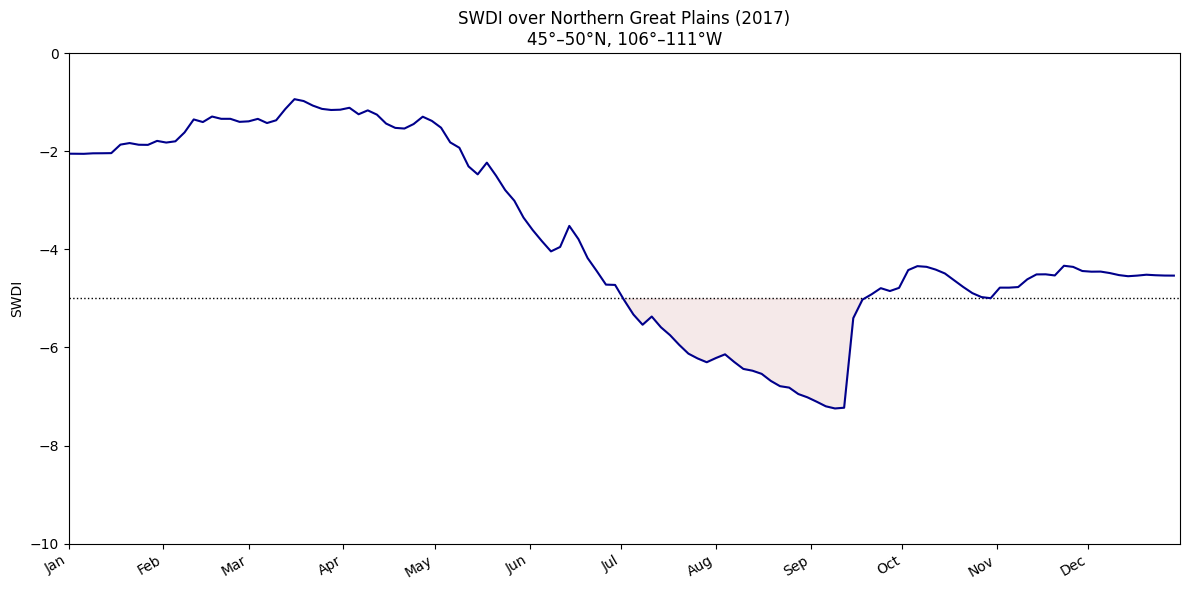

In [23]:
swdi_fname = "data/swdi_timeseries.csv"

plot_dates = []
plot_swdi: list[float] = []
with open(swdi_fname, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        plot_dates.append(datetime.strptime(row["time"], "%Y-%m-%d"))
        plot_swdi.append(float(row["swdi"]))

# In this plot, we can highlight the period where the SWDI signal
# was indicating flash drought, i.e. it was persistently below -5
flash_drought_swdi = [r < -5 for r in plot_swdi]

fig, ax = plt.subplots(figsize=(12, 6))
ax.axhline(-5, color="black", linestyle=":", linewidth=1)
ax.plot(plot_dates, plot_swdi, color="darkblue", linewidth=1.5)
ax.set_ylim(-10, 0)
#print()
#print(end_date)
ax.set_xlim(left=mdates.datestr2num("2017-01-01"), right=mdates.datestr2num("2017-12-31"))
ax.fill_between(plot_dates, plot_swdi, -5, where=flash_drought_swdi, color="brown", alpha=0.1)
ax.set_ylabel("SWDI")
ax.set_title(f"SWDI over Northern Great Plains ({year})\n45°–50°N, 106°–111°W")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()